In [3]:
# Импортируем базовые библиотеки для работы с данными и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль графиков для красивого отображения в отчете
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Загрузка датасета
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Размер датасета: {df.shape}")
display(df.head())

Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Просмотр типов данных
df.info()

# Колонка TotalCharges имеет тип object, хотя там должны быть числа. Исправляем это:
# errors='coerce' превратит некорректные значения (пробелы) в NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Проверим количество пропусков
print("\nПропуски в данных до очистки:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Пропусков всего 11 (это новые клиенты, у которых tenure = 0). 
# Для простоты baseline-решения просто удалим эти строки.
df.dropna(inplace=True)

# Удалим колонку customerID, так как она не несет предиктивной ценности
df.drop('customerID', axis=1, inplace=True)

print(f"\nРазмер датасета после очистки: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


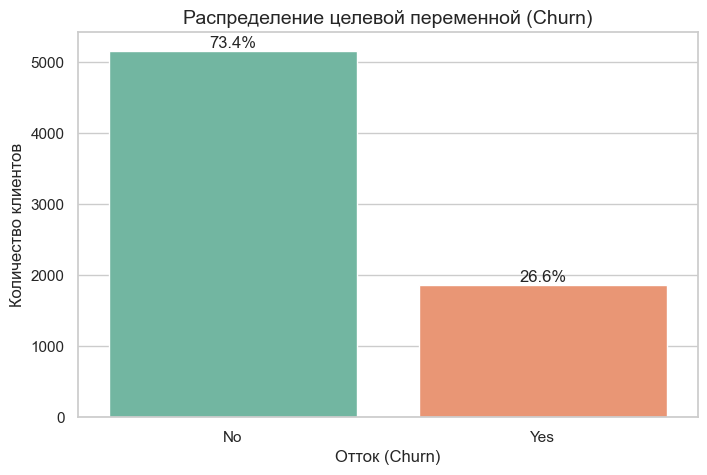

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Распределение целевой переменной (Churn)', fontsize=14)
plt.xlabel('Отток (Churn)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

# Добавим проценты на столбцы для наглядности
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.show()

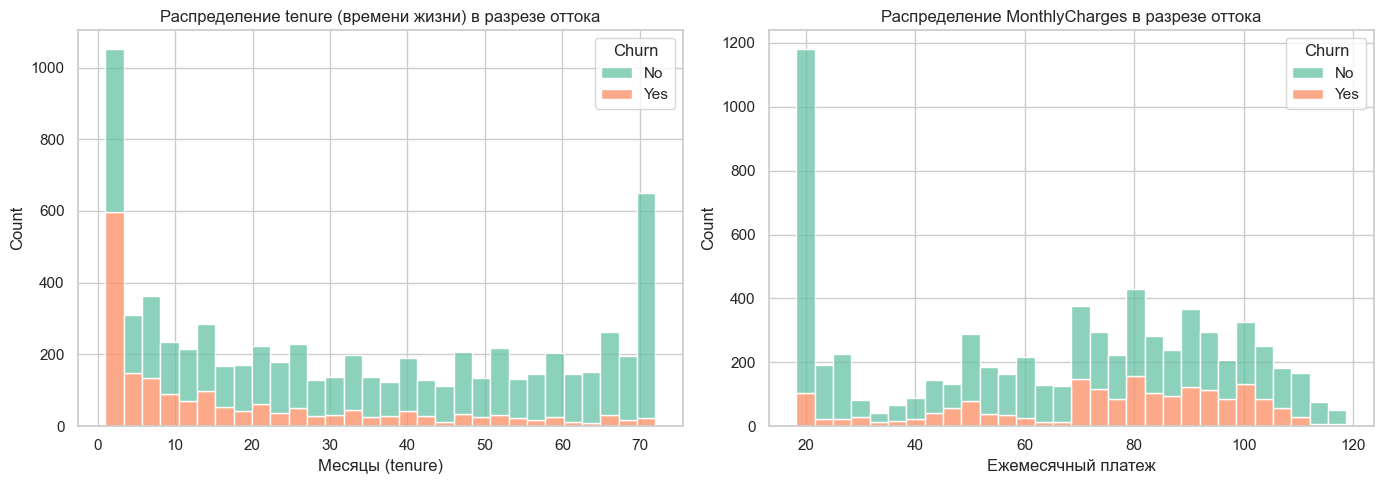

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение времени жизни клиента (tenure)
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0], palette='Set2', bins=30)
axes[0].set_title('Распределение tenure (времени жизни) в разрезе оттока')
axes[0].set_xlabel('Месяцы (tenure)')

# Распределение ежемесячных платежей
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1], palette='Set2', bins=30)
axes[1].set_title('Распределение MonthlyCharges в разрезе оттока')
axes[1].set_xlabel('Ежемесячный платеж')

plt.tight_layout()
plt.show()

In [8]:
# Преобразуем целевую переменную в числа: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

import os
# Создаем директорию data, если её нет (важно для структуры проекта)
os.makedirs('../data', exist_ok=True)

# Сохраняем очищенные данные
clean_data_path = '../data/telco_cleaned.csv'
df.to_csv(clean_data_path, index=False)

print(f"Очищенные данные успешно сохранены по пути: {clean_data_path}")

Очищенные данные успешно сохранены по пути: ../data/telco_cleaned.csv
